In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("PyTorch version:", torch.__version__)
print("Environment ready.")

PyTorch version: 2.2.2+cpu
Environment ready.


In [40]:
print("Loading optimized small combined dataset...")
df = pd.read_csv('../data/processed/combined_dataset_small.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Loading optimized small combined dataset...
Shape: (1315200, 12)
Columns: ['zone_id', 'date', 'daytype', 'hour', 'demand', 'is_weekend', 'temp_max', 'temp_min', 'precipitation', 'rain', 'weather_code', 'is_raining']


,zone_id,date,daytype,hour,demand,is_weekend,temp_max,temp_min,precipitation,rain,weather_code,is_raining
0,ZONE_41.7200_-87.6250,2019-01-01,U,0,2.49,1,2.3,-1.5,6.0,3.6,73,1
1,ZONE_41.7200_-87.6250,2019-01-01,U,1,1.25,1,2.3,-1.5,6.0,3.6,73,1
2,ZONE_41.7200_-87.6250,2019-01-01,U,2,0.50,1,2.3,-1.5,6.0,3.6,73,1
3,ZONE_41.7200_-87.6250,2019-01-01,U,3,0.50,1,2.3,-1.5,6.0,3.6,73,1
4,ZONE_41.7200_-87.6250,2019-01-01,U,4,1.25,1,2.3,-1.5,6.0,3.6,73,1


In [41]:
print("Normalizing demand per zone to stabilize training baseline...")
# 1. Normalize demand per zone: (x - mean) / std
df['demand_normalized'] = df.groupby('zone_id')['demand'].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-8)
)
print("Demand stats after per-zone normalization:")
print(df['demand_normalized'].describe())

print("\nPreparing features and targets...")
# Add day_of_week and month to features as requested
df['day_of_week'] = pd.to_datetime(df['date']).dt.dayofweek
df['month'] = pd.to_datetime(df['date']).dt.month

# Select expanded features for the model
features = ['hour', 'is_weekend', 'temp_max', 'temp_min',
            'precipitation', 'is_raining', 'weather_code',
            'day_of_week', 'month']

target = 'demand_normalized'

X = df[features]
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Normalizing demand per zone to stabilize training baseline...
Demand stats after per-zone normalization:
count    1.315200e+06
mean    -1.270679e-17
std      9.999814e-01
min     -9.546135e-01
25%     -7.706363e-01
50%     -2.571723e-01
75%      4.921657e-01
max      4.584772e+00
Name: demand_normalized, dtype: float64

Preparing features and targets...
Features shape: (1315200, 9)
Target shape: (1315200,)


In [42]:
print("Scaling features and target to [0, 1] range...")
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1,1))

print("Scaled X range:", X_scaled.min(), "to", X_scaled.max())
print("Scaled y range:", y_scaled.min(), "to", y_scaled.max())

Scaling features and target to [0, 1] range...
Scaled X range: 0.0 to 1.0
Scaled y range: 0.0 to 1.0


In [43]:
print("Creating sequences geolocalised per zone to prevent spatial leakage...")

def create_zone_sequences(df, X_scaled, y_scaled, sequence_length=24):
    X_seq, y_seq = [], []
    y_orig = []
    y_mean = []
    y_std = []
    
    # Group indices by zone to build sequences within each zone's boundary only
    zone_groups = df.groupby('zone_id')
    
    print("Processing sequences for each of the top 50 zones...")
    for zone_id, group in zone_groups:
        indices = group.index
        X_zone = X_scaled[indices]
        y_zone = y_scaled[indices]
        
        y_orig_zone = df.loc[indices, 'demand'].values
        mean_val = group['demand'].mean()
        std_val = group['demand'].std() + 1e-8
        
        for i in range(len(X_zone) - sequence_length):
            X_seq.append(X_zone[i:i+sequence_length])
            y_seq.append(y_zone[i+sequence_length])
            y_orig.append(y_orig_zone[i+sequence_length])
            y_mean.append(mean_val)
            y_std.append(std_val)
            
    return np.array(X_seq), np.array(y_seq), np.array(y_orig), np.array(y_mean), np.array(y_std)

sequence_length = 24  # Look at the last 24 hours to predict the next hour
X_seq, y_seq, y_orig, y_mean, y_std = create_zone_sequences(df, X_scaled, y_scaled, sequence_length)

print("Sequence shape:", X_seq.shape)
print("Target shape:", y_seq.shape)

Creating sequences geolocalised per zone to prevent spatial leakage...
Processing sequences for each of the top 50 zones...
Sequence shape: (1314000, 24, 9)
Target shape: (1314000, 1)


In [44]:
print("Splitting train and test datasets (Chronologically)......")
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    random_state=42,
    shuffle=False  # Important for time-series splits
)

# Chronological split for the metadata used in denormalization
_, _, _, y_test_orig = train_test_split(X_seq, y_orig, test_size=0.2, random_state=42, shuffle=False)
_, _, _, y_test_mean = train_test_split(X_seq, y_mean, test_size=0.2, random_state=42, shuffle=False)
_, _, _, y_test_std = train_test_split(X_seq, y_std, test_size=0.2, random_state=42, shuffle=False)

print("Training samples:", X_train_np.shape)
print("Testing samples:", X_test_np.shape)

Splitting train and test datasets (Chronologically)......
Training samples: (1051200, 24, 9)
Testing samples: (262800, 24, 9)


In [45]:
print("Converting datasets to PyTorch Tensors and DataLoader...")
# Convert to float32 tensors (standard PyTorch precision)
X_train_t = torch.tensor(X_train_np, dtype=torch.float32)
y_train_t = torch.tensor(y_train_np, dtype=torch.float32)
X_test_t = torch.tensor(X_test_np, dtype=torch.float32)
y_test_t = torch.tensor(y_test_np, dtype=torch.float32)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_t, y_train_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

# DataLoader with optimized batch size for high-speed training on CPU
train_loader = DataLoader(train_dataset, batch_size=1024, shuffle=False)

print("Train loader created with batch size 1024.")

Converting datasets to PyTorch Tensors and DataLoader...
Train loader created with batch size 1024.


In [46]:
print("Building the LSTM network model using PyTorch...")

class LSTMDemandModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.2):
        super(LSTMDemandModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_dim, 16)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(16, output_dim)
        
    def forward(self, x):
        # Initialise hidden states
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        # Take output of the last sequential time step
        out = out[:, -1, :]
        out = self.relu(self.fc1(out))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

model = LSTMDemandModel(input_dim=len(features))
print(model)

Building the LSTM network model using PyTorch...
LSTMDemandModel(
  (lstm): LSTM(9, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc1): Linear(in_features=64, out_features=16, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [47]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
import shutil

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
criterion = nn.MSELoss()

best_loss = float('inf')
patience_counter = 0
early_stop_patience = 7

print("Starting training with Early Stopping (max 100 epochs)...\n")

for epoch in range(100):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    scheduler.step(avg_loss)
    print(f"Epoch {epoch+1:03d} | Loss: {avg_loss:.6f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        patience_counter = 0
        torch.save(model.state_dict(), '../models/saved/demand_model_best.pth')
        print(f"  ✓ Best model saved at epoch {epoch+1}")
    else:
        patience_counter += 1
        if patience_counter >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\nBest loss achieved: {round(best_loss, 6)}")
# Ensure compatibility by copying the best weights to demand_model.pth
os.makedirs('../models/saved', exist_ok=True)
shutil.copyfile('../models/saved/demand_model_best.pth', '../models/saved/demand_model.pth')
print("Best model weights successfully copied to /models/saved/demand_model.pth")
print("Training complete.")

Starting training with Early Stopping (max 100 epochs)...

Epoch 001 | Loss: 0.025886
  ✓ Best model saved at epoch 1
Epoch 002 | Loss: 0.013311
  ✓ Best model saved at epoch 2
Epoch 003 | Loss: 0.011950
  ✓ Best model saved at epoch 3
Epoch 004 | Loss: 0.011505
  ✓ Best model saved at epoch 4
Epoch 005 | Loss: 0.011025
  ✓ Best model saved at epoch 5
Epoch 006 | Loss: 0.010913
  ✓ Best model saved at epoch 6
Epoch 007 | Loss: 0.011056
Epoch 008 | Loss: 0.010618
  ✓ Best model saved at epoch 8
Epoch 009 | Loss: 0.010642
Epoch 010 | Loss: 0.010807
Epoch 011 | Loss: 0.010800
Epoch 012 | Loss: 0.010344
  ✓ Best model saved at epoch 12
Epoch 013 | Loss: 0.010205
  ✓ Best model saved at epoch 13
Epoch 014 | Loss: 0.010260
Epoch 015 | Loss: 0.009890
  ✓ Best model saved at epoch 15
Epoch 016 | Loss: 0.009752
  ✓ Best model saved at epoch 16
Epoch 017 | Loss: 0.009644
  ✓ Best model saved at epoch 17
Epoch 018 | Loss: 0.009558
  ✓ Best model saved at epoch 18
Epoch 019 | Loss: 0.009248
  ✓ Be

In [48]:
print("Loading best saved model for evaluation...")
model.load_state_dict(torch.load('../models/saved/demand_model_best.pth'))
model.eval()

batch_size = 1024
y_pred_list = []

with torch.no_grad():
    for i in range(0, len(X_test_t), batch_size):
        X_batch = X_test_t[i:i+batch_size]
        pred_batch = model(X_batch)
        y_pred_list.append(pred_batch.numpy())

y_pred_scaled = np.concatenate(y_pred_list, axis=0)
y_pred_normalized = scaler_y.inverse_transform(y_pred_scaled)
y_pred = y_pred_normalized.flatten() * y_test_std + y_test_mean
y_actual = y_test_orig

mae = mean_absolute_error(y_actual, y_pred)
rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
avg_demand = df['demand'].mean()
accuracy = (1 - mae/avg_demand) * 100

print("\n--- Model Performance Statistics ---")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("Average demand:", round(avg_demand, 2))
print("Model accuracy:", round(accuracy, 2), "%")

Loading best saved model for evaluation...

--- Model Performance Statistics ---
MAE: 1.9
RMSE: 2.8
Average demand: 17.09
Model accuracy: 88.9 %


Plotting actual vs predicted demand curve...


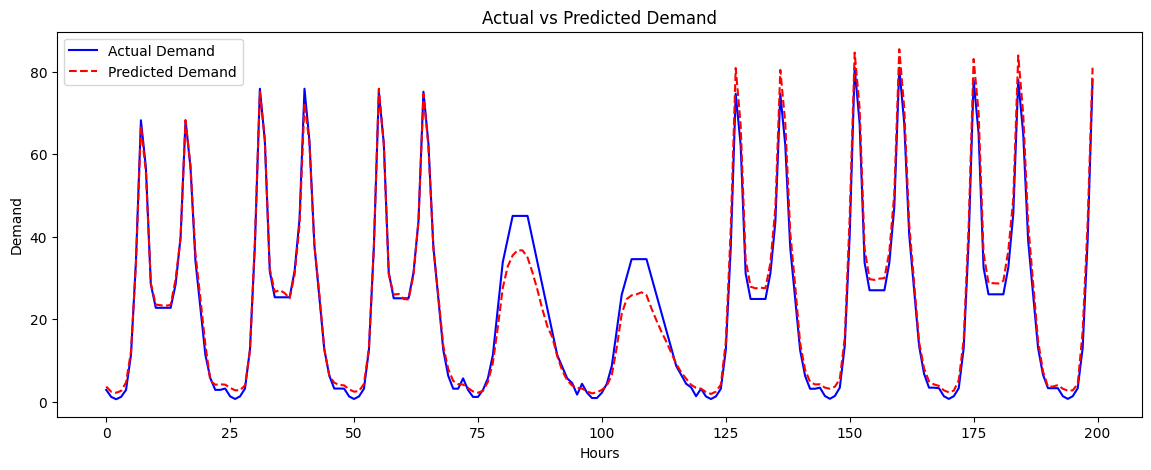

In [49]:
print("Plotting actual vs predicted demand curve...")
plt.figure(figsize=(14,5))
plt.plot(y_actual[:200], label='Actual Demand', color='blue')
plt.plot(y_pred[:200], label='Predicted Demand', color='red', linestyle='--')
plt.title('Actual vs Predicted Demand')
plt.xlabel('Hours')
plt.ylabel('Demand')
plt.legend()
plt.show()

In [50]:
print("Saving trained model weights...")
os.makedirs('../models/saved', exist_ok=True)

# Save model in standard PyTorch state dictionary format
torch.save(model.state_dict(), '../models/saved/demand_model.pth')
print("Model saved successfully inside /models/saved/demand_model.pth")

Saving trained model weights...
Model saved successfully inside /models/saved/demand_model.pth
